## MBFC 

In [5]:
import pandas as pd
import re
from urllib.parse import urlparse


from collections import Counter

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-colorblind')

In [6]:


bsky = pd.read_csv('clean/bsky_posts_clean.csv')
truth = pd.read_csv('clean/truth_posts_clean.csv', dtype={'post_id': str})

def extract_urls(text):
    if pd.isna(text):
        return []
    return re.findall(r'https?://[^\s<>"{}|\\^`\[\]]+', str(text))

def extract_domain(url):
    try:
        domain = urlparse(url).netloc.lower()
        if domain.startswith('www.'):
            domain = domain[4:]
        return domain
    except:
        return None

bsky['urls'] = bsky['text'].apply(extract_urls)
bsky['url_count'] = bsky['urls'].apply(len)
truth['urls'] = truth['text'].apply(extract_urls)
truth['url_count'] = truth['urls'].apply(len)

print(f"Bluesky: {len(bsky):,} posts ({bsky['url_count'].gt(0).sum():,} with URLs)")
print(f"Truth:   {len(truth):,} posts ({truth['url_count'].gt(0).sum():,} with URLs)")

Bluesky: 1,529,104 posts (119,857 with URLs)
Truth:   48,086 posts (29,165 with URLs)


In [7]:

# Load MBFC lookup
mbfc = pd.read_csv('Factual-Reporting-and-Political-Bias-Web-Interactions/data/mbfc.csv')
mbfc_lookup = dict(zip(mbfc['source'], mbfc[['bias', 'factual_reporting']].to_dict('records')))
print(f"MBFC entries: {len(mbfc_lookup)}")

# Match domains to MBFC
def get_mbfc(urls):
    for url in urls:
        d = extract_domain(url)
        if d and d in mbfc_lookup:
            return mbfc_lookup[d]
    return None

for df, name in [(bsky, 'BLUESKY'), (truth, 'TRUTH SOCIAL')]:
    df['mbfc'] = df['urls'].apply(get_mbfc)
    df['mbfc_bias'] = df['mbfc'].apply(lambda x: x['bias'] if x else None)
    df['mbfc_factuality'] = df['mbfc'].apply(lambda x: x['factual_reporting'] if x else None)

    with_urls = df[df['url_count'] > 0]
    classified = df[df['mbfc_bias'].notna()]

    print(f"\n{name}")
    print(f"  Posts with URLs:       {len(with_urls):,}")
    print(f"  Matched to MBFC:       {len(classified):,} ({len(classified)/max(len(with_urls),1)*100:.1f}%)")
    print(f"\n  Bias:\n{classified['mbfc_bias'].value_counts().to_string()}")
    print(f"\n  Factuality:\n{classified['mbfc_factuality'].value_counts().to_string()}")

MBFC entries: 3875

BLUESKY
  Posts with URLs:       119,857
  Matched to MBFC:       14,830 (12.4%)

  Bias:
mbfc_bias
left-center     8497
neutral         3876
right-center    1365
left             941
right            151

  Factuality:
mbfc_factuality
high     10112
mixed     4676
low         42

TRUTH SOCIAL
  Posts with URLs:       29,165
  Matched to MBFC:       7,157 (24.5%)

  Bias:
mbfc_bias
right           5595
left-center      567
right-center     429
neutral          408
left             158

  Factuality:
mbfc_factuality
low      3658
mixed    2755
high      744


In [8]:
# sample domains 


bsky_domains = []
for urls in bsky['urls']:
    for url in urls:
        d = extract_domain(url)
        if d:
            bsky_domains.append(d)

print("Top 20 domains in your Bluesky data:")
for domain, count in Counter(bsky_domains).most_common(20):
    print(f"  {domain}: {count}")

print(f"\nSample MBFC keys:")
for key in list(mbfc_lookup.keys())[:20]:
    print(f"  '{key}'")

Top 20 domains in your Bluesky data:
  arxiv.org: 6616
  t.co: 3895
  amzn.to: 3594
  chatgpt.com: 3473
  u2m.io: 3217
  bit.ly: 2512
  news.ycombinator.com: 2487
  buff.ly: 2269
  medium.com: 1590
  community.openai.com: 1477
  fundspec.io: 1460
  youtube.com: 1389
  zip358.com: 1252
  github.com: 1225
  tinyurl.com: 1203
  theverge.com: 1088
  techcrunch.com: 1020
  gigazine.net: 925
  youtu.be: 856
  aepprotocol.xyz: 814

Sample MBFC keys:
  '9news.com'
  'nbc11news.com'
  '12news.com'
  'wibw.com'
  'wifr.com'
  '247wallst.com'
  '24ur.com'
  '38north.org'
  'audacy.com'
  'join1440.com'
  'abc7chicago.com'
  'abc7ny.com'
  'abc12.com'
  'abs-cbn.com'
  'actionnewsjax.com'
  'adfontesmedia.com'
  'lenconnect.com'
  'adweek.com'
  'africacheck.org'
  'agdaily.com'


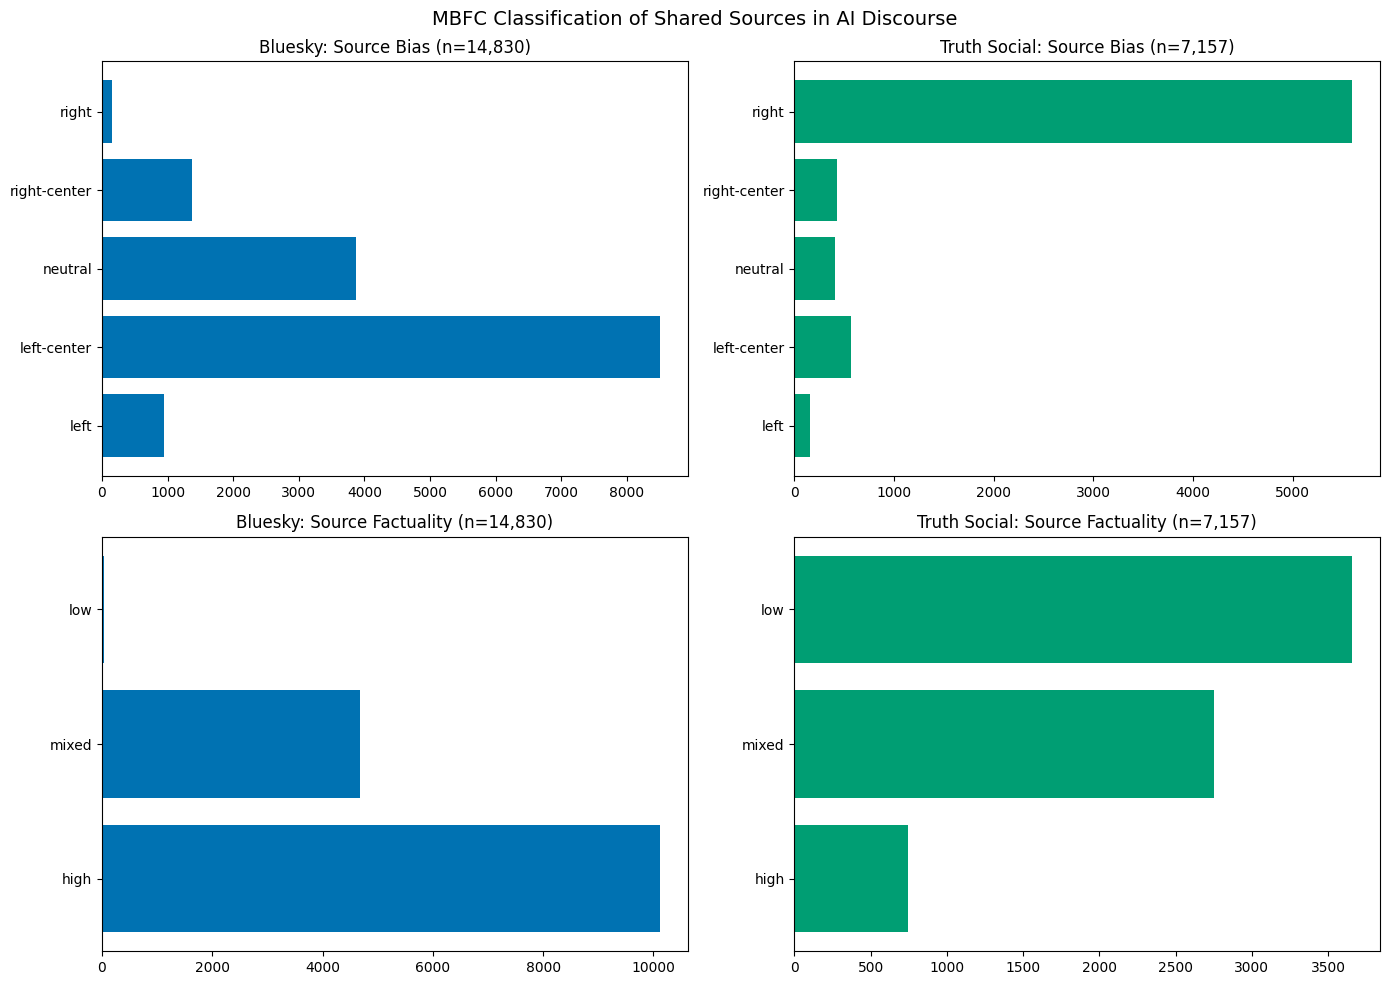

In [9]:

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_bsky = colors[0]
color_truth = colors[1]


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

bias_order = ['left', 'left-center', 'neutral', 'right-center', 'right']
fact_order = ['high', 'mixed', 'low']


for i, (df, name, color) in enumerate([(bsky, 'Bluesky', color_bsky), (truth, 'Truth Social', color_truth)]):
    classified = df[df['mbfc_bias'].notna()]
    
    bias = classified['mbfc_bias'].value_counts().reindex(bias_order, fill_value=0)
    axes[0, i].barh(bias.index, bias.values, color=color)
    axes[0, i].set_title(f'{name}: Source Bias (n={len(classified):,})')
    
    fact = classified['mbfc_factuality'].value_counts().reindex(fact_order, fill_value=0)
    axes[1, i].barh(fact.index, fact.values, color=color)
    axes[1, i].set_title(f'{name}: Source Factuality (n={len(classified):,})')

plt.suptitle('MBFC Classification of Shared Sources in AI Discourse', fontsize=14)
plt.tight_layout()
plt.show()

# Edge lists with MBFC incorporated 

In [ ]:
# Author-level MBFC profiles
def get_author_mbfc(posts_df, author_col):
    records = []
    for author, group in posts_df.groupby(author_col):
        bias_counts = Counter()
        fact_counts = Counter()
        for text in group['text']:
            for url in extract_urls(text):
                d = extract_domain(url)
                if d and d in mbfc_lookup:
                    bias_counts[mbfc_lookup[d]['bias']] += 1
                    fact_counts[mbfc_lookup[d]['factual_reporting']] += 1
        records.append({
            author_col: author,
            'mbfc_bias': bias_counts.most_common(1)[0][0] if bias_counts else None,
            'mbfc_factuality': fact_counts.most_common(1)[0][0] if fact_counts else None,
            'mbfc_sources_count': sum(bias_counts.values()),
        })
    return pd.DataFrame(records)


bsky_author_mbfc = get_author_mbfc(bsky, 'author_did')
truth_author_mbfc = get_author_mbfc(truth, 'author_id')
print(f"  Bluesky: {bsky_author_mbfc['mbfc_bias'].notna().sum():,} authors with profile")
print(f"  Truth:   {truth_author_mbfc['mbfc_bias'].notna().sum():,} authors with profile")

In [13]:
# Load edge lists and author MBFC profiles
bsky_edges = pd.read_csv('clean/bsky_repost_edgelist.csv')
truth_edges = pd.read_csv('clean/truth_repost_edgelist.csv', dtype={'source': str, 'target': str})

# Add source and target MBFC attributes
# Bluesky 
bsky_edges = bsky_edges.merge(
    bsky_author_mbfc.rename(columns={'author_did': 'source', 'mbfc_bias': 'source_bias', 'mbfc_factuality': 'source_factuality', 'mbfc_sources_count': 'source_mbfc_count'}),
    on='source', how='left'
).merge(
    bsky_author_mbfc.rename(columns={'author_did': 'target', 'mbfc_bias': 'target_bias', 'mbfc_factuality': 'target_factuality', 'mbfc_sources_count': 'target_mbfc_count'}),
    on='target', how='left'
)
bsky_edges.to_csv('clean/bsky_repost_edgelist_updated.csv', index=False)
print(f"Bluesky edges: {len(bsky_edges):,}")
print(bsky_edges.head())

# Truth Social 
truth_author_mbfc['author_id'] = truth_author_mbfc['author_id'].astype(str)
truth_edges = truth_edges.merge(
    truth_author_mbfc.rename(columns={'author_id': 'source', 'mbfc_bias': 'source_bias', 'mbfc_factuality': 'source_factuality', 'mbfc_sources_count': 'source_mbfc_count'}),
    on='source', how='left'
).merge(
    truth_author_mbfc.rename(columns={'author_id': 'target', 'mbfc_bias': 'target_bias', 'mbfc_factuality': 'target_factuality', 'mbfc_sources_count': 'target_mbfc_count'}),
    on='target', how='left'
)
truth_edges.to_csv('clean/truth_repost_edgelist_updated.csv', index=False)
print(f"Truth edges: {len(truth_edges):,}")
print(truth_edges.head())




Bluesky edges: 1,577,684
                             source                            target  weight  \
0  did:plc:222p42fegwhwfyrc3gqam76j  did:plc:2bngtbjbuisgz74oblcdvhfj       1   
1  did:plc:222p42fegwhwfyrc3gqam76j  did:plc:2cadvbwpkxtuvmv2gpy5laml       1   
2  did:plc:222p42fegwhwfyrc3gqam76j  did:plc:2wfmbc2rbodcexiiyms4yh6x       1   
3  did:plc:222p42fegwhwfyrc3gqam76j  did:plc:46haijs5rxtkat6bijis2ltd       1   
4  did:plc:222p42fegwhwfyrc3gqam76j  did:plc:53xy3x3zo33lg6ukj2xuefye       1   

  source_bias source_factuality  source_mbfc_count target_bias  \
0         NaN               NaN                  0         NaN   
1         NaN               NaN                  0         NaN   
2         NaN               NaN                  0         NaN   
3         NaN               NaN                  0         NaN   
4         NaN               NaN                  0         NaN   

  target_factuality  target_mbfc_count  
0               NaN                NaN  
1        

In [14]:
print(f"Bluesky authors with MBFC: {bsky_author_mbfc['mbfc_bias'].notna().sum():,}")
print(f"Truth Social authors with MBFC: {truth_author_mbfc['mbfc_bias'].notna().sum():,}")


Bluesky authors with MBFC: 2,658
Truth Social authors with MBFC: 1,171


In [16]:
# again but with more scoring 

def get_author_mbfc2(posts_df, author_col):
    records = []
    for author, group in posts_df.groupby(author_col):
        bias_counts = Counter()
        fact_counts = Counter()
        for text in group['text']:
            for url in extract_urls(text):
                d = extract_domain(url)
                if d and d in mbfc_lookup:
                    bias_counts[mbfc_lookup[d]['bias']] += 1
                    fact_counts[mbfc_lookup[d]['factual_reporting']] += 1
        total = sum(bias_counts.values())
        records.append({
            author_col: author,
            'mbfc_sources_count': total,
            # majority label
            'mbfc_bias': bias_counts.most_common(1)[0][0] if bias_counts else None,
            'mbfc_factuality': fact_counts.most_common(1)[0][0] if fact_counts else None,
            # confidence: proportion of sources matching majority label
            'bias_confidence': bias_counts.most_common(1)[0][1] / total if total > 0 else None,
            'fact_confidence': fact_counts.most_common(1)[0][1] / total if total > 0 else None,
            # mixed flag: True if no single label accounts for >70%
            'mixed_sources': (bias_counts.most_common(1)[0][1] / total < 0.7) if total > 1 else False,
        })
    return pd.DataFrame(records)



In [17]:
# version 2 profiles

bsky_author_mbfc2 = get_author_mbfc2(bsky, 'author_did')
truth_author_mbfc2 = get_author_mbfc2(truth, 'author_id')
truth_author_mbfc2['author_id'] = truth_author_mbfc2['author_id'].astype(str)

print(f"Bluesky: {bsky_author_mbfc2['mbfc_bias'].notna().sum():,} authors with profile")
print(f"Truth:   {truth_author_mbfc2['mbfc_bias'].notna().sum():,} authors with profile")
print(f"\nBluesky mixed sources: {bsky_author_mbfc2['mixed_sources'].sum():,}")
print(f"Truth mixed sources:   {truth_author_mbfc2['mixed_sources'].sum():,}")

Computing v2 author MBFC profiles...
Bluesky: 2,658 authors with profile
Truth:   1,171 authors with profile

Bluesky mixed sources: 401
Truth mixed sources:   136


In [18]:
# Build v2 edge lists
bsky_edges2 = pd.read_csv('clean/bsky_repost_edgelist.csv')
bsky_edges2 = bsky_edges2.merge(
    bsky_author_mbfc2.rename(columns={'author_did': 'source', 'mbfc_bias': 'source_bias', 'mbfc_factuality': 'source_factuality', 'mbfc_sources_count': 'source_mbfc_count', 'bias_confidence': 'source_bias_conf', 'fact_confidence': 'source_fact_conf', 'mixed_sources': 'source_mixed'}),
    on='source', how='left'
).merge(
    bsky_author_mbfc2.rename(columns={'author_did': 'target', 'mbfc_bias': 'target_bias', 'mbfc_factuality': 'target_factuality', 'mbfc_sources_count': 'target_mbfc_count', 'bias_confidence': 'target_bias_conf', 'fact_confidence': 'target_fact_conf', 'mixed_sources': 'target_mixed'}),
    on='target', how='left'
)
bsky_edges2.to_csv('clean/bsky_repost_edgelist_v2.csv', index=False)
print(f"Bluesky v2: {len(bsky_edges2):,} edges")

truth_edges2 = pd.read_csv('clean/truth_repost_edgelist.csv', dtype={'source': str, 'target': str})
truth_edges2 = truth_edges2.merge(
    truth_author_mbfc2.rename(columns={'author_id': 'source', 'mbfc_bias': 'source_bias', 'mbfc_factuality': 'source_factuality', 'mbfc_sources_count': 'source_mbfc_count', 'bias_confidence': 'source_bias_conf', 'fact_confidence': 'source_fact_conf', 'mixed_sources': 'source_mixed'}),
    on='source', how='left'
).merge(
    truth_author_mbfc2.rename(columns={'author_id': 'target', 'mbfc_bias': 'target_bias', 'mbfc_factuality': 'target_factuality', 'mbfc_sources_count': 'target_mbfc_count', 'bias_confidence': 'target_bias_conf', 'fact_confidence': 'target_fact_conf', 'mixed_sources': 'target_mixed'}),
    on='target', how='left'
)
truth_edges2.to_csv('clean/truth_repost_edgelist_v2.csv', index=False)
print(f"Truth v2: {len(truth_edges2):,} edges")

Bluesky v2: 1,577,684 edges
Truth v2: 24,056 edges


In [19]:
# Show a few authors who share multiple sources
active = bsky_author_mbfc2[bsky_author_mbfc2['mbfc_sources_count'] >= 3].head(10)
print("Bluesky authors with 3+ MBFC sources:")
print(active[['author_did', 'mbfc_bias', 'mbfc_factuality', 'bias_confidence', 'fact_confidence', 'mixed_sources', 'mbfc_sources_count']].to_string())

print(f"\nExample: author who shared 5 sources, labelled '{active.iloc[0]['mbfc_bias']}' with {active.iloc[0]['bias_confidence']:.0%} confidence, mixed={active.iloc[0]['mixed_sources']}")

Bluesky authors with 3+ MBFC sources:
                            author_did     mbfc_bias mbfc_factuality  bias_confidence  fact_confidence  mixed_sources  mbfc_sources_count
123   did:plc:22g7l55edwo5z2gddhfkemtm       neutral            high         0.571429         1.000000           True                   7
1453  did:plc:26hkfmtr7jrchexamh7hk6rz   left-center            high         0.666667         0.666667           True                   9
2765  did:plc:2cjklenwyqtowe7kvujr5xls       neutral            high         1.000000         1.000000          False                   7
5235  did:plc:2jwxoziacifmtqa5felhqms6       neutral            high         1.000000         1.000000          False                   3
5270  did:plc:2jzjitfrch66fq3n6ouixan7  right-center            high         1.000000         1.000000          False                   8
5873  did:plc:2lsaehavsy452fhsyn4udcvv   left-center            high         1.000000         1.000000          False                 